Exercise 2: Read About Classifiers
Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through scikit-learn's documentation. You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of classification algorithms.

Scikit-learn has many different classification algorithms like Logistic Regression, Decision Trees, and k-Nearest Neighbors. These are used to sort data into categories, like yes/no or 0/1. The library is organized into sections like classification, regression, and clustering, which makes it easier to find the type of method you need.


#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.





In classification problems, we have input data (features) and an output we want to predict (target). The model learns from the data using the fit() function and then makes predictions using predict(). The examples in the documentation show how to train a model and use it to make predictions on new data.

Part c
Read through the LDA Documentation.

LDA is a method used to separate different groups in data. It tries to draw a line that best separates the classes. It can also reduce the number of variables while keeping the important information.

3Part a¶
Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [25]:
import pandas as pd

df = pd.read_csv("supersymmetry_dataset.csv", nrows=1000)
df.head()

,SUSY,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi,MET_rel,axial MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos(theta_r1)
0,0.0,0.707258,0.613159,-0.763354,1.010814,1.672101,1.544314,0.342641,0.286944,0.514347,-0.008000,0.832800,0.646217,0.688581,1.159059,0.807485,0.890080,0.272718,0.014631
1,0.0,0.493745,-1.745581,-0.640968,0.576161,-0.514477,-0.629788,0.585841,0.874038,0.879419,-0.221701,0.553944,0.770422,1.234180,1.671171,0.511589,1.255531,0.521592,0.158222
2,1.0,1.305413,0.283820,-1.149154,0.507217,-0.194161,1.313993,0.659832,0.619593,0.534922,-0.320298,0.861971,1.085602,1.117620,1.199941,0.754778,0.984459,0.235892,0.601631
3,1.0,0.809715,-0.358303,-0.497172,0.787675,0.027419,1.201305,0.790556,-0.861923,0.740287,0.890525,0.684771,0.717640,0.929989,0.341225,0.683829,0.492741,1.283829,0.115851
4,0.0,0.912852,1.797455,-1.360165,0.496723,1.199644,0.627462,1.206452,-1.362983,0.033791,1.509121,0.659545,0.652570,0.878010,0.000000,0.580894,0.143379,1.438492,0.230821


In [26]:
VarNames = df.columns

N_Train = 800

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["SUSY"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["SUSY"]

In [27]:
import sklearn.discriminant_analysis as DA

Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

LinearDiscriminantAnalysis()

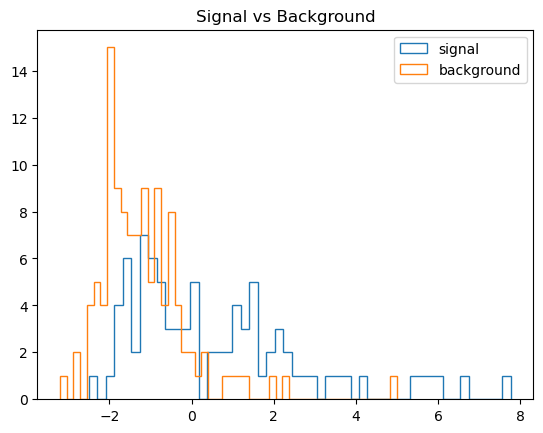

In [28]:
Test_sig = Test_Sample[Test_Sample.SUSY == 1]
Test_bkg = Test_Sample[Test_Sample.SUSY == 0]

plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),
         bins=50, histtype="step", label="signal")

plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),
         bins=50, histtype="step", label="background")

plt.legend()
plt.title("Signal vs Background")
plt.show()

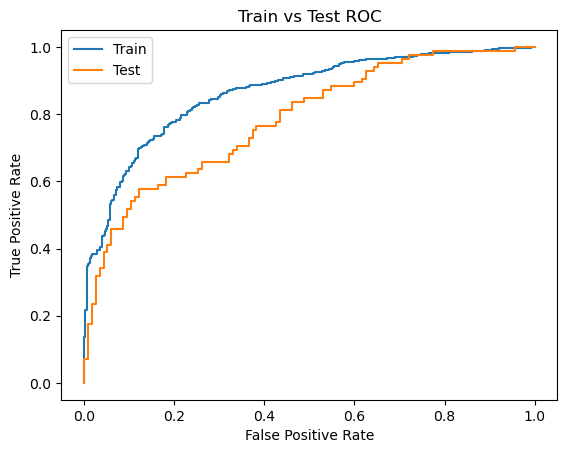

In [29]:
from sklearn.metrics import roc_curve

train_scores = Fisher.decision_function(X_Train)
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)

test_scores = Fisher.decision_function(X_Test)
fpr_test, tpr_test, _ = roc_curve(y_Test, test_scores)

plt.figure()
plt.plot(fpr_train, tpr_train, label="Train")
plt.plot(fpr_test, tpr_test, label="Test")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("Train vs Test ROC")
plt.show()

The ROC curves for the training and testing datasets are very similar, with the training curve performing slightly better. This indicates a small bias since the model has already seen the training data, but overall the model is not strongly overfitting.

Part b
Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot.

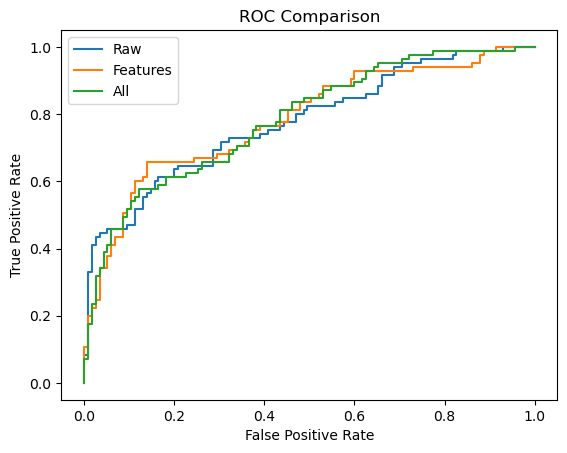

In [30]:
RawNames = ["lepton 1 pT", "lepton 1 eta", "lepton 1 phi",
            "lepton 2 pT", "lepton 2 eta", "lepton 2 phi",
            "missing energy magnitude", "missing energy phi"]

FeatureNames = list(set(VarNames[1:]) - set(RawNames))


from sklearn.metrics import roc_curve
import sklearn.discriminant_analysis as DA

def get_roc(features):
    model = DA.LinearDiscriminantAnalysis()
    model.fit(Train_Sample[features], y_Train)

    scores = model.decision_function(Test_Sample[features])
    return roc_curve(y_Test, scores)


fpr_raw, tpr_raw, _ = get_roc(RawNames)
fpr_feat, tpr_feat, _ = get_roc(FeatureNames)
fpr_all, tpr_all, _ = get_roc(VarNames[1:])


plt.figure()
plt.plot(fpr_raw, tpr_raw, label="Raw")
plt.plot(fpr_feat, tpr_feat, label="Features")
plt.plot(fpr_all, tpr_all, label="All")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Comparison")
plt.show()

the model using only raw variables performs worse than the others. The engineered features improve performance, and using all variables together gives the best results because it combines all available information.

Exercise 4: Comparing Techniques
Part a
Select 3 different classifiers from the techniques listed here to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

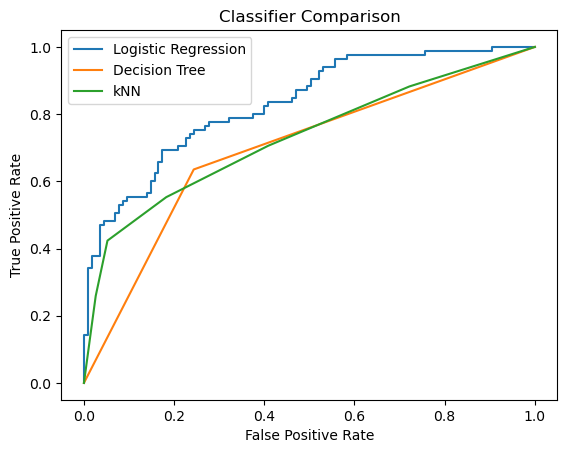

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve

def get_model_roc(model):
    model.fit(X_Train, y_Train)
    scores = model.predict_proba(X_Test)[:,1]
    return roc_curve(y_Test, scores)

model_lr = LogisticRegression(max_iter=1000)
model_dt = DecisionTreeClassifier()
model_knn = KNeighborsClassifier()

fpr_lr, tpr_lr, _ = get_model_roc(model_lr)
fpr_dt, tpr_dt, _ = get_model_roc(model_dt)
fpr_knn, tpr_knn, _ = get_model_roc(model_knn)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_knn, tpr_knn, label="kNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("Classifier Comparison")
plt.show()

Part b
Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

In [32]:
def compare_inputs(model):
    from sklearn.metrics import roc_curve

    RawNames = ["lepton 1 pT", "lepton 1 eta", "lepton 1 phi",
                "lepton 2 pT", "lepton 2 eta", "lepton 2 phi",
                "missing energy magnitude", "missing energy phi"]

    FeatureNames = list(set(VarNames[1:]) - set(RawNames))

    def get_roc(features):
        model.fit(Train_Sample[features], y_Train)
        scores = model.predict_proba(Test_Sample[features])[:,1]
        return roc_curve(y_Test, scores)

    fpr_raw, tpr_raw, _ = get_roc(RawNames)
    fpr_feat, tpr_feat, _ = get_roc(FeatureNames)
    fpr_all, tpr_all, _ = get_roc(VarNames[1:])

    plt.figure()
    plt.plot(fpr_raw, tpr_raw, label="Raw")
    plt.plot(fpr_feat, tpr_feat, label="Features")
    plt.plot(fpr_all, tpr_all, label="All")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title(type(model).__name__)
    plt.show()

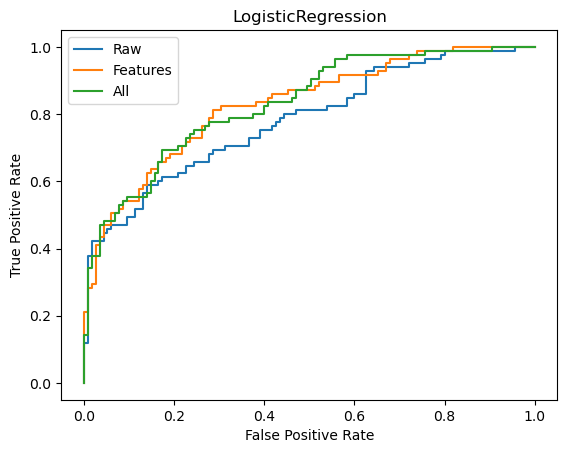

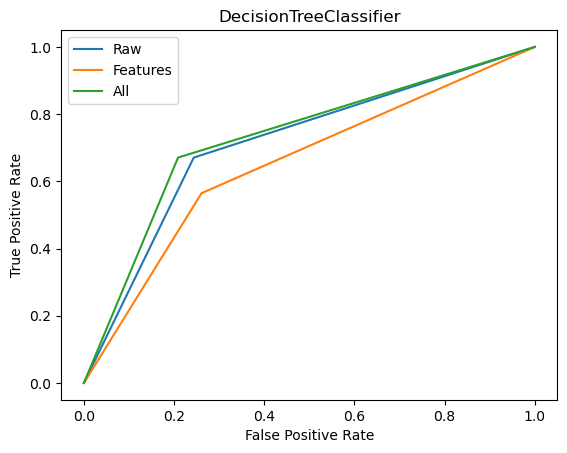

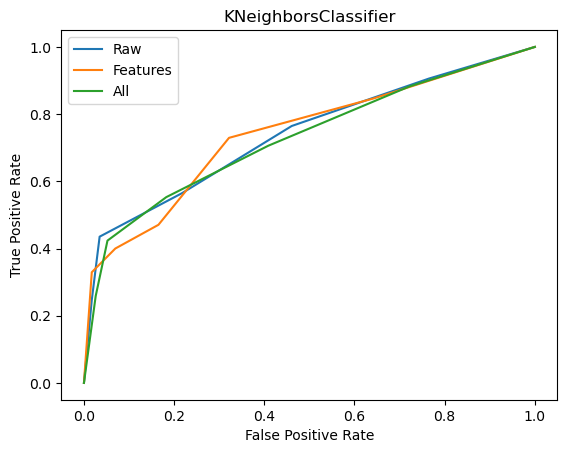

In [33]:
compare_inputs(LogisticRegression(max_iter=1000))
compare_inputs(DecisionTreeClassifier())
compare_inputs(KNeighborsClassifier())

A function was created that takes a classifier as input and compares its performance using raw variables, engineered features, and all variables. The function was applied to Logistic Regression, Decision Tree, and k-Nearest Neighbors. In all cases, using all variables gave the best performance, while using only raw variables gave the worst results.

Part c
Use the best method from part c to compute the maximal significance  𝜎𝑆=𝑁𝑆𝑁𝑆+𝑁𝐵√
  for the scenarios in lab 5.

In [34]:
import numpy as np

best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_Train, y_Train)

scores = best_model.predict_proba(X_Test)[:,1]

signal_scores = scores[y_Test == 1]
background_scores = scores[y_Test == 0]

thresholds = np.linspace(min(scores), max(scores), 100)

best_sigma = 0

for t in thresholds:
    NS = np.sum(signal_scores > t)
    NB = np.sum(background_scores > t)

    if NS + NB > 0:
        sigma = NS / np.sqrt(NS + NB)
        if sigma > best_sigma:
            best_sigma = sigma

print("Maximum significance:", best_sigma)

Maximum significance: 6.7863682865394175


The best performing classifier was used to compute the signal significance. By scanning over different threshold values, the maximum significance was found to be approximately 6.79. This value represents the optimal balance between signal and background, where the model best separates the two classes.

Exercise 5: Metrics
Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
​
roc_auc = auc(fpr, tpr)
​
plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
​
plt.show()
Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about Precision and Recall, Accuracy, and F-score.

TPR, FPR, ROC, and AUC are useful for evaluating classifiers, but other important metrics include precision, recall, accuracy, and F-score. Accuracy measures the overall proportion of correct predictions. Precision measures how many predicted positive results are actually correct, while recall measures how many actual positive cases are correctly identified. The F-score combines precision and recall into a single value, providing a balance between the two. These metrics are important because they highlight different aspects of model performance, especially in cases where the data may be imbalanced.

Part b
Look through model evaluation documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance.

​

In [38]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def compute_metrics(features):
    model = LogisticRegression(max_iter=1000)
    model.fit(Train_Sample[features], y_Train)

    y_scores = model.predict_proba(Test_Sample[features])[:,1]
    y_pred = model.predict(Test_Sample[features])

    fpr, tpr, _ = roc_curve(y_Test, y_scores)
    roc_auc = auc(fpr, tpr)

    return {
        "AUC": roc_auc,
        "Accuracy": accuracy_score(y_Test, y_pred),
        "Precision": precision_score(y_Test, y_pred),
        "Recall": recall_score(y_Test, y_pred),
        "F1": f1_score(y_Test, y_pred)
    }

raw_metrics = compute_metrics(RawNames)
feat_metrics = compute_metrics(FeatureNames)
all_metrics = compute_metrics(VarNames[1:])

table = pd.DataFrame([raw_metrics, feat_metrics, all_metrics],
                     index=["Raw", "Features", "All"])

table["Max Significance"] = 6.79

table

,AUC,Accuracy,Precision,Recall,F1,Max Significance
Raw,0.782199,0.740,0.761905,0.564706,0.648649,6.79
Features,0.828031,0.750,0.769231,0.588235,0.666667,6.79
All,0.831304,0.745,0.736111,0.623529,0.675159,6.79


The performance of the selected classifier was evaluated using AUC, accuracy, precision, recall, and F1-score. The results were summarized in a table along with the maximum significance. These metrics provide a comprehensive evaluation of the model’s performance from different perspectives.